# Dự đoán điểm cuối kỳ bằng TensorFlow Computational Graph

**Môn học:** Cấu trúc dữ liệu và giải thuật nâng cao  
**Giảng viên:** Nguyễn Thanh Sơn  
**Sinh viên:** Đặng Minh Nhiên  
**GitHub:** https://github.com/MichaelSkyman/Final_score_prediction

Notebook này trình bày đầy đủ quá trình xây dựng mô hình dự đoán điểm cuối kỳ dựa trên điểm giữa kỳ. Mô hình được cài đặt bằng TensorFlow computational graph và tối ưu bằng Batch Gradient Descent.

## 1. Ý tưởng phương pháp

Bài toán có một biến đầu vào là điểm giữa kỳ `midterm` và một biến mục tiêu là điểm cuối kỳ `final`, vì vậy có thể mô hình hóa bằng hồi quy tuyến tính một biến.

Mô hình trên dữ liệu đã chuẩn hóa:

$$z = \frac{x - \mu}{\sigma}$$

$$\hat{y} = b + wz$$

Hàm mất mát:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i} - y_i)^2$$

Sau khi huấn luyện, công thức được đổi về thang điểm gốc:

$$\hat{y} = b_0 + b_1x$$

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image as PILImage
from IPython.display import Image, display

ROOT = Path.cwd().parents[0] if Path.cwd().name == "src" else Path.cwd()
DATA_PATH = ROOT / "data" / "TRAIN2.xlsx"
OUTPUT_DIR = ROOT / "outputs"

tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)
print("Dataset:", DATA_PATH)

TensorFlow version: 2.21.0
Dataset: D:\Final_score_prediction\data\TRAIN2.xlsx


## 2. Đọc và kiểm tra dữ liệu

In [2]:
df = pd.read_excel(DATA_PATH)
df = df[["midterm", "final"]].copy()
df["midterm"] = pd.to_numeric(df["midterm"], errors="coerce")
df["final"] = pd.to_numeric(df["final"], errors="coerce")
df = df.dropna().reset_index(drop=True)

display(df.head())
display(df.describe())
print("Số mẫu:", len(df))

,midterm,final
0,0.70,2.56
1,0.97,2.78
2,5.43,6.35
3,4.99,5.99
4,7.09,7.67


,midterm,final
count,515.000000,515.000000
mean,5.038136,6.032544
std,2.928851,2.343196
min,0.030000,2.030000
25%,2.385000,3.910000
50%,5.040000,6.030000
75%,7.605000,8.085000
max,9.960000,9.970000


Số mẫu: 515


## 3. Chia tập train/test

Dữ liệu được chia 80% để huấn luyện và 20% để kiểm tra. Seed cố định giúp kết quả có thể tái lập.

In [3]:
def split_train_test(dataframe, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(dataframe))
    test_size = max(1, round(len(dataframe) * test_ratio))
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]
    return dataframe.iloc[train_idx].reset_index(drop=True), dataframe.iloc[test_idx].reset_index(drop=True)

train_df, test_df = split_train_test(df)
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (412, 2)
Test: (103, 2)


## 4. Xây dựng TensorFlow Computational Graph

Graph có cấu trúc:

```text
Input(midterm) -> Normalization -> Dense(1) -> y_hat -> MSE loss
```

Trong đó:
- `Normalization` học mean và variance của điểm giữa kỳ.
- `Dense(1)` biểu diễn công thức tuyến tính.
- Loss là Mean Squared Error.
- Tối ưu bằng Batch Gradient Descent: mỗi epoch dùng toàn bộ tập train để tính gradient rồi cập nhật tham số một lần.

In [4]:
x_train = train_df["midterm"].to_numpy(dtype="float32").reshape(-1, 1)
y_train = train_df["final"].to_numpy(dtype="float32").reshape(-1, 1)

normalizer = tf.keras.layers.Normalization(axis=None, name="normalize_midterm")
normalizer.adapt(x_train)

graph = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(1,), name="midterm"),
        normalizer,
        tf.keras.layers.Dense(1, name="linear_output"),
    ],
    name="final_score_tensorflow_graph",
)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)
loss_fn = tf.keras.losses.MeanSquaredError()

graph.summary()

Model: "final_score_tensorflow_graph"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalize_midterm               │ (None, 1)              │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_output (Dense)           │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

## 5. Huấn luyện bằng Batch Gradient Descent

In [5]:
epochs = 160
losses = []
x_tensor = tf.convert_to_tensor(x_train)
y_tensor = tf.convert_to_tensor(y_train)

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_hat = graph(x_tensor, training=True)
        loss = loss_fn(y_tensor, y_hat)
    gradients = tape.gradient(loss, graph.trainable_variables)
    optimizer.apply_gradients(zip(gradients, graph.trainable_variables))
    losses.append(float(loss.numpy()))

print("Loss đầu:", losses[0])
print("Loss cuối:", losses[-1])

Loss đầu: 38.41042709350586
Loss cuối: 8.297817657876294e-06


## 6. Lấy công thức dự báo sau huấn luyện

In [6]:
dense = graph.get_layer("linear_output")
kernel, bias_array = dense.get_weights()

graph_weight = float(kernel[0, 0])
graph_bias = float(bias_array[0])
feature_mean = float(np.ravel(normalizer.mean.numpy())[0])
feature_std = float(np.sqrt(np.ravel(normalizer.variance.numpy())[0]))

slope = graph_weight / feature_std
intercept = graph_bias - (graph_weight * feature_mean / feature_std)

print(f"Dạng graph đã chuẩn hóa: y_hat = {graph_bias:.6f} + {graph_weight:.6f} * z")
print(f"mean = {feature_mean:.6f}, std = {feature_std:.6f}")
print(f"Công thức trên thang điểm gốc: final = {intercept:.6f} + {slope:.6f} * midterm")

Dạng graph đã chuẩn hóa: y_hat = 6.106090 + 2.301960 * z
mean = 5.130073, std = 2.877395
Công thức trên thang điểm gốc: final = 2.001954 + 0.800015 * midterm


## 7. Đánh giá mô hình

In [7]:
def predict(midterm_values):
    midterm_values = np.asarray(midterm_values, dtype="float32")
    return intercept + slope * midterm_values

def clip_scores(values):
    return np.clip(values, 0, 10)

def compute_metrics(y_true, y_pred):
    errors = y_true - y_pred
    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(errors)))
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot else 0.0
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

y_test = test_df["final"].to_numpy(dtype="float32")
y_pred = clip_scores(predict(test_df["midterm"].to_numpy(dtype="float32")))
metrics = compute_metrics(y_test, y_pred)

pd.DataFrame([metrics])

,MAE,MSE,RMSE,R2
0,0.002296,0.000007,0.00271,0.999999


## 8. Nhận xét về kết quả

Mô hình có sai số rất nhỏ. Điều này không phải vì mô hình quá phức tạp, mà vì dataset có quan hệ gần như tuyến tính tuyệt đối:

$$final \approx 2 + 0.8 \times midterm$$

Mô hình học được công thức rất gần:

$$final = 2.001954 + 0.800015 \times midterm$$

Vì vậy kết quả gần như không lệch là hợp lý với dataset hiện tại. Tuy nhiên, với dữ liệu học tập thực tế hơn, kết quả này có thể hơi lạc quan vì điểm cuối kỳ còn phụ thuộc vào nhiều yếu tố khác như bài tập, chuyên cần, độ khó đề thi và mức độ ôn tập.

## 9. Đồ thị tính toán và kết quả

computation_graph.png


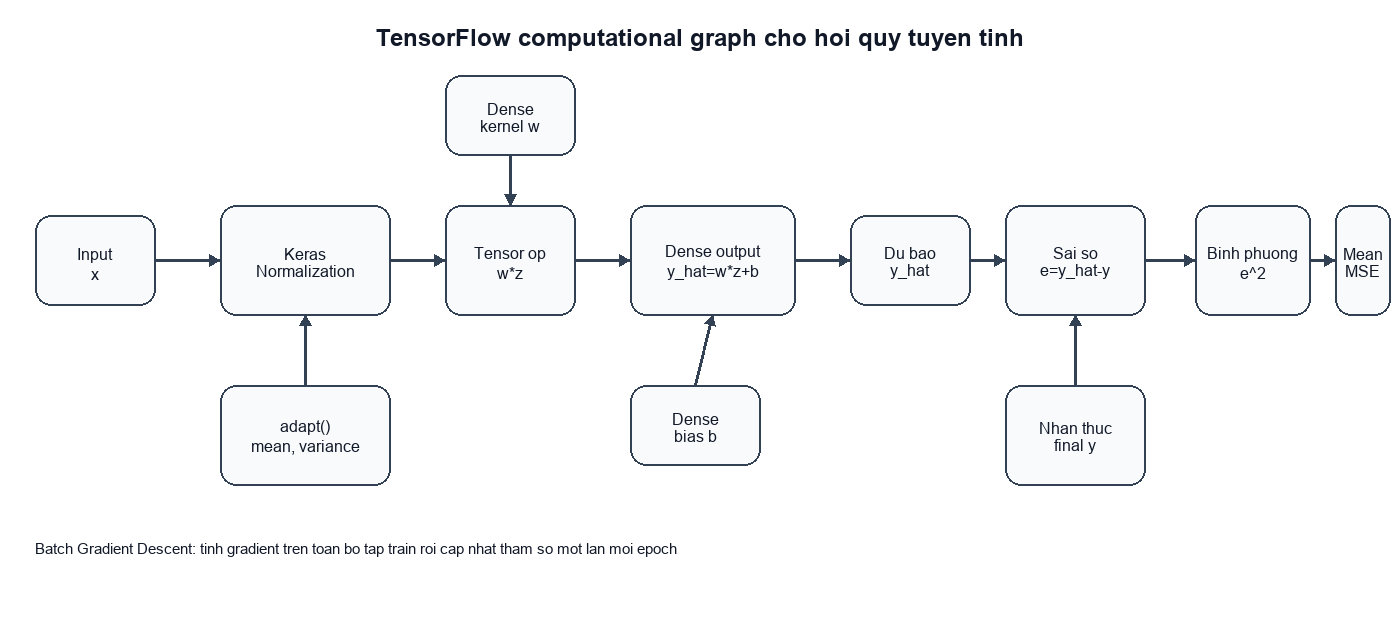

regression_plot.png


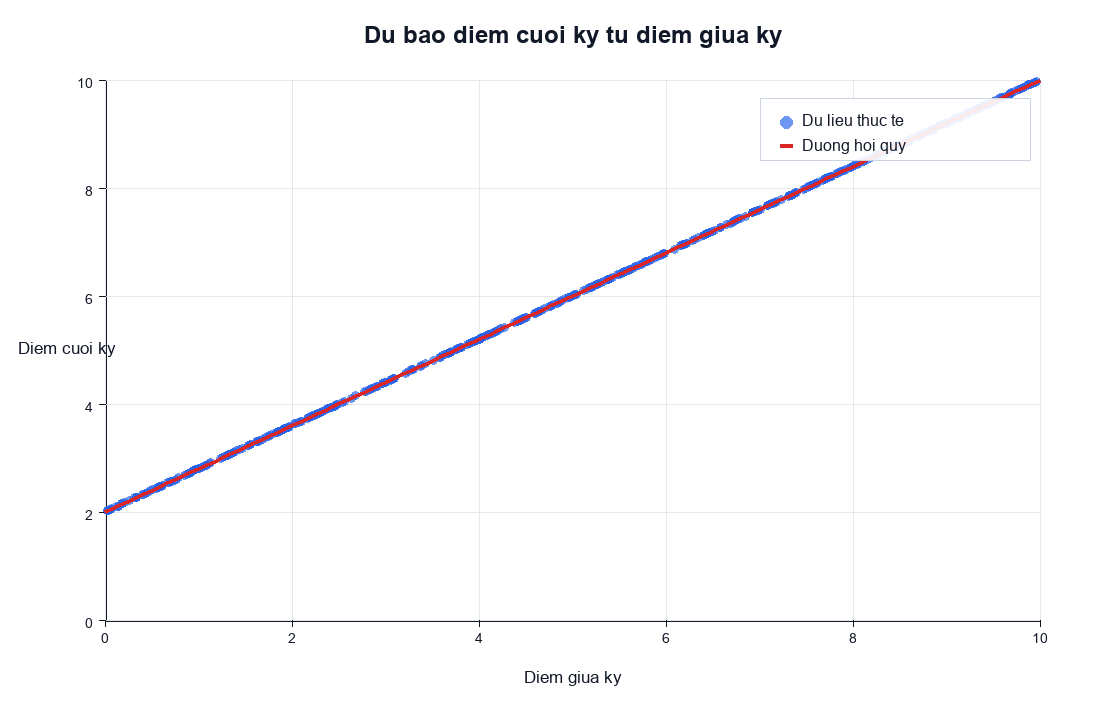

residual_plot.png


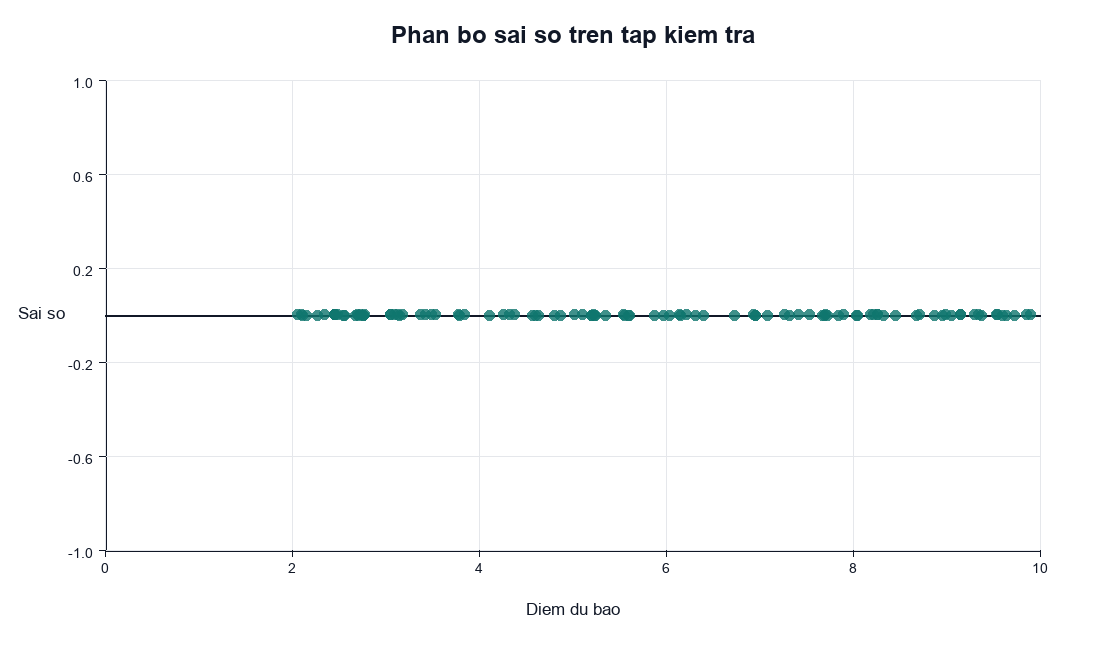

loss_plot.png


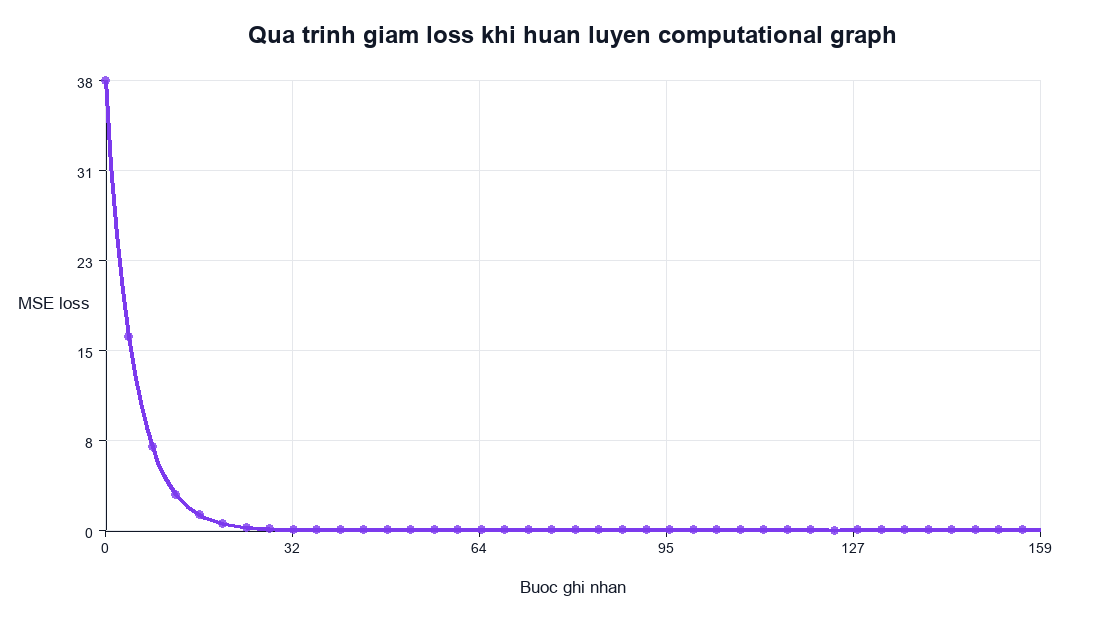

In [8]:
for image_name in [
    "computation_graph.png",
    "regression_plot.png",
    "residual_plot.png",
    "loss_plot.png",
]:
    image_path = OUTPUT_DIR / image_name
    print(image_name)
    display(Image(filename=str(image_path)))

## 10. Dự đoán thử

In [9]:
midterm_example = 7.5
predicted_final = float(clip_scores(predict([midterm_example]))[0])
print(f"Điểm giữa kỳ: {midterm_example}")
print(f"Điểm cuối kỳ dự đoán: {predicted_final:.4f}")

Điểm giữa kỳ: 7.5
Điểm cuối kỳ dự đoán: 8.0021
